<a href="https://colab.research.google.com/github/paolaCaushi/anomalyDetection/blob/transferLearning_Trying/transferLearningPerpjekjeDeshtim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. preprocess the first dataset



In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# Load the first dataset
data_file_1 = "Anomalie_2021_2024.xlsx"
df_1 = pd.read_excel(data_file_1, sheet_name="Sheet1", header=0)

# Create target variable based on 'idPunto' being null and 'note' being 12 or 6
df_1['Target'] = df_1.apply(lambda row: 1 if pd.isnull(row['idPunto']) and row['note'] in [12, 6] else 0, axis=1)

# Drop the 'idPunto' and 'note' columns
df_1 = df_1.drop(columns=['idPunto', 'note'])

# Convert datetime columns to numeric
datetime_columns_1 = ['dataAnomalia', 'dataCoordinate', 'dataSegnalazione']
for col in datetime_columns_1:
    df_1[col] = pd.to_datetime(df_1[col], errors='coerce').astype('int64') // 10**9

# Fill NaN values in datetime columns with median
for col in datetime_columns_1:
    df_1[col].fillna(df_1[col].median(), inplace=True)

# Convert categorical columns to string type
categorical_features_1 = df_1.select_dtypes(include=['object']).columns
df_1[categorical_features_1] = df_1[categorical_features_1].astype(str)

# Separate features and target variable in the first dataset
X_1 = df_1.drop(columns=['Target'])
y_1 = df_1['Target']

# Identify numeric and categorical features
numeric_features_1 = X_1.select_dtypes(include=['int64', 'float64']).columns
categorical_features_1 = X_1.select_dtypes(include=['object']).columns

# Define preprocessing pipelines for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_1),
        ('cat', categorical_transformer, categorical_features_1)])

# Preprocess the first dataset
X_1 = preprocessor.fit_transform(X_1)

# Split the first dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

# Train the XGBoost model on the first dataset
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {accuracy_xgb}')
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.8674914536871235
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.93     36357
           1       0.73      0.23      0.35      6644

    accuracy                           0.87     43001
   macro avg       0.80      0.61      0.64     43001
weighted avg       0.85      0.87      0.84     43001



In [30]:
# Train the XGBoost model on the first dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {accuracy_xgb}')
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Calculate ROC-AUC score
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f'XGBoost ROC-AUC Score: {roc_auc_xgb}')

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)


XGBoost Accuracy: 0.8674914536871235
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.93     36357
           1       0.73      0.23      0.35      6644

    accuracy                           0.87     43001
   macro avg       0.80      0.61      0.64     43001
weighted avg       0.85      0.87      0.84     43001

XGBoost ROC-AUC Score: 0.8920318148459445


In [21]:
# Load the second dataset
data_file_2 = "uniqueWorldwide.xlsx"
df_2 = pd.read_excel(data_file_2, sheet_name="Sheet1", header=0)

# Map the columns from the second dataset to match the first dataset
column_mapping = {
    'Codice': 'idAnomalia',
    'CodiceTipo': 'note',
    'DataOraRicezione': 'dataAnomalia',
    'Latitudine': 'latitudine',
    'Longitudine': 'longitudine',
    # Assuming 'dataCoordinate' and 'dataSegnalazione' can be mapped to relevant columns in df_2 if available
    'DataOraRilevazione': 'dataCoordinate',
    'DataOraCreazione': 'dataSegnalazione',
    'Semirimorchio':'idConcentratore'
}

df_2 = df_2.rename(columns=column_mapping)

# Convert datetime columns to numeric
datetime_columns_2 = ['dataAnomalia', 'dataCoordinate', 'dataSegnalazione']
for col in datetime_columns_2:
    df_2[col] = pd.to_datetime(df_2[col], errors='coerce').astype('int64') // 10**9

# Fill NaN values in datetime columns with median
for col in datetime_columns_2:
    df_2[col].fillna(df_2[col].median(), inplace=True)

# Convert categorical columns to string type
categorical_features_2 = df_2.select_dtypes(include=['object']).columns
df_2[categorical_features_2] = df_2[categorical_features_2].astype(str)

# Preprocess the second dataset
X_2 = preprocessor.transform(df_2)


In [22]:
# Predict anomalies on the second dataset
y_pred_2 = xgb_model.predict(X_2)
y_pred_proba_2 = xgb_model.predict_proba(X_2)[:, 1]

# Add predictions to the second dataset
df_2['AnomalyPrediction'] = y_pred_2
df_2['AnomalyProbability'] = y_pred_proba_2

# Save the results to an Excel file
output_file = "uniqueWorldwide_with_anomalies.xlsx"
df_2.to_excel(output_file, index=False)

output_file


'uniqueWorldwide_with_anomalies.xlsx'

XGBoost Accuracy: 0.8674914536871235
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.93     36357
           1       0.73      0.23      0.35      6644

    accuracy                           0.87     43001
   macro avg       0.80      0.61      0.64     43001
weighted avg       0.85      0.87      0.84     43001

XGBoost ROC-AUC Score: 0.8920318148459445
Total records: 733
Predicted anomalies: 0
Anomaly ratio: 0.0000


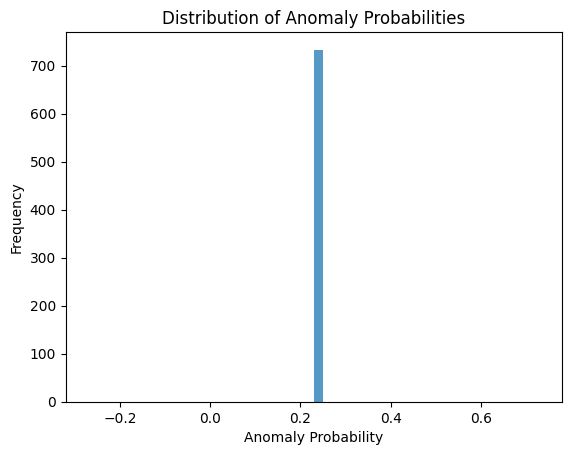

In [17]:
# Load the necessary libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Load the first dataset
data_file_1 = "Anomalie_2021_2024.xlsx"
df_1 = pd.read_excel(data_file_1, sheet_name="Sheet1", header=0)

# Create target variable based on 'idPunto' being null and 'note' being 12 or 6
df_1['Target'] = df_1.apply(lambda row: 1 if pd.isnull(row['idPunto']) and row['note'] in [12, 6] else 0, axis=1)

# Drop the 'idPunto' and 'note' columns
df_1 = df_1.drop(columns=['idPunto', 'note'])

# Convert datetime columns to numeric
datetime_columns_1 = ['dataAnomalia', 'dataCoordinate', 'dataSegnalazione']
for col in datetime_columns_1:
    df_1[col] = pd.to_datetime(df_1[col], errors='coerce').astype('int64') // 10**9

# Fill NaN values in datetime columns with median
for col in datetime_columns_1:
    df_1[col].fillna(df_1[col].median(), inplace=True)

# Convert categorical columns to string type
categorical_features_1 = df_1.select_dtypes(include=['object']).columns
df_1[categorical_features_1] = df_1[categorical_features_1].astype(str)

# Separate features and target variable in the first dataset
X_1 = df_1.drop(columns=['Target'])
y_1 = df_1['Target']

# Identify numeric and categorical features
numeric_features_1 = X_1.select_dtypes(include=['int64', 'float64']).columns
categorical_features_1 = X_1.select_dtypes(include=['object']).columns

# Define preprocessing pipelines for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_1),
        ('cat', categorical_transformer, categorical_features_1)])

# Preprocess the first dataset
X_1 = preprocessor.fit_transform(X_1)

# Split the first dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

# Train the XGBoost model on the first dataset
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the XGBoost model
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {accuracy_xgb}')
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Calculate ROC-AUC score
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f'XGBoost ROC-AUC Score: {roc_auc_xgb}')

# Load the second dataset
data_file_2 = "uniqueWorldwide.xlsx"
df_2 = pd.read_excel(data_file_2, sheet_name="Sheet1", header=0)

# Map the columns from the second dataset to match the first dataset
column_mapping = {
    'Codice': 'idAnomalia',
    'CodiceTipo': 'note',
    'DataOraRicezione': 'dataAnomalia',
    'Latitudine': 'latitudine',
    'Longitudine': 'longitudine',
    'DataOraRilevazione': 'dataCoordinate',
    'DataOraCreazione': 'dataSegnalazione',
    'Semirimorchio': 'idConcentratore'
}

df_2 = df_2.rename(columns=column_mapping)

# Convert datetime columns to numeric
datetime_columns_2 = ['dataAnomalia', 'dataCoordinate', 'dataSegnalazione']
for col in datetime_columns_2:
    df_2[col] = pd.to_datetime(df_2[col], errors='coerce').astype('int64') // 10**9

# Fill NaN values in datetime columns with median
for col in datetime_columns_2:
    df_2[col].fillna(df_2[col].median(), inplace=True)

# Convert categorical columns to string type
categorical_features_2 = df_2.select_dtypes(include=['object']).columns
df_2[categorical_features_2] = df_2[categorical_features_2].astype(str)

# Ensure all necessary columns are present
necessary_columns = list(numeric_features_1) + list(categorical_features_1)
for col in necessary_columns:
    if col not in df_2.columns:
        df_2[col] = np.nan

# Preprocess the second dataset
X_2 = preprocessor.transform(df_2)

# Predict anomalies on the second dataset
y_pred_2 = xgb_model.predict(X_2)
y_pred_proba_2 = xgb_model.predict_proba(X_2)[:, 1]

# Add predictions to the second dataset
df_2['AnomalyPrediction'] = y_pred_2
df_2['AnomalyProbability'] = y_pred_proba_2

# Analyze the predicted anomalies
anomaly_count = df_2['AnomalyPrediction'].sum()
total_count = len(df_2)
anomaly_ratio = anomaly_count / total_count

print(f'Total records: {total_count}')
print(f'Predicted anomalies: {anomaly_count}')
print(f'Anomaly ratio: {anomaly_ratio:.4f}')

# Plot the distribution of anomaly probabilities
plt.hist(df_2['AnomalyProbability'], bins=50, alpha=0.75)
plt.title('Distribution of Anomaly Probabilities')
plt.xlabel('Anomaly Probability')
plt.ylabel('Frequency')
plt.show()

# Save the results to an Excel file
output_file = "uniqueWorldwide_with_anomalies_2.xlsx"
df_2.to_excel(output_file, index=False)


XGBoost Accuracy (Combined Dataset): 1.0
XGBoost Classification Report (Combined Dataset):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       985
           1       1.00      1.00      1.00       162

    accuracy                           1.00      1147
   macro avg       1.00      1.00      1.00      1147
weighted avg       1.00      1.00      1.00      1147

XGBoost ROC-AUC Score (Combined Dataset): 1.0


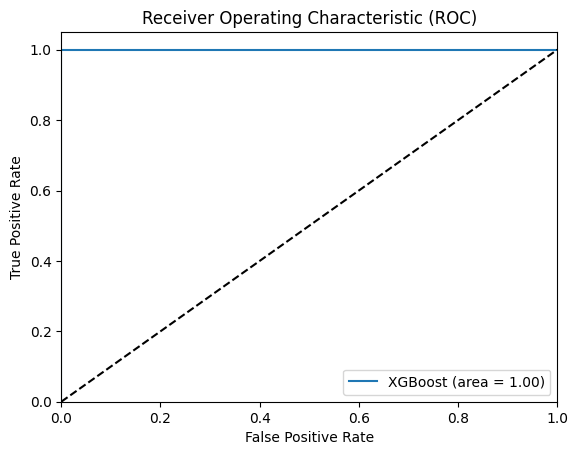

Total records: 1147
Predicted anomalies: 162
Anomaly ratio: 0.1412


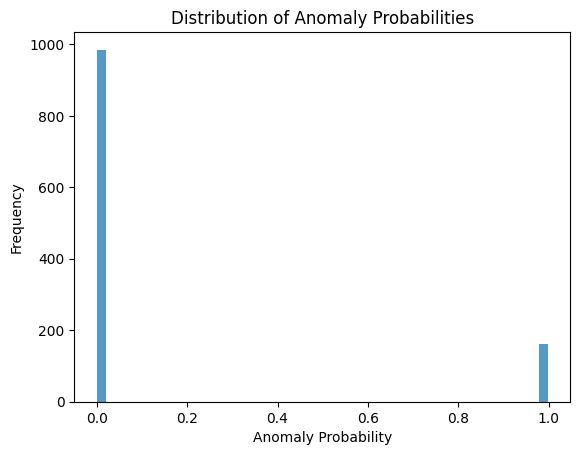

In [31]:
# Load the first dataset to get the structure
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split



# Load the existing anomalies
data_file_2 = "uniqueWorldwide.xlsx"
df_2 = pd.read_excel(data_file_2, sheet_name="Sheet1", header=0)

# Map the columns from the second dataset to match the first dataset
column_mapping = {
    'Codice': 'idAnomalia',
    'CodiceTipo': 'note',
    'DataOraRicezione': 'dataAnomalia',
    'Latitudine': 'latitudine',
    'Longitudine': 'longitudine',
    'DataOraRilevazione': 'dataCoordinate',
    'DataOraCreazione': 'dataSegnalazione',
    'Semirimorchio': 'idConcentratore'
}

df_2 = df_2.rename(columns=column_mapping)

# Convert datetime columns to numeric
datetime_columns_2 = ['dataAnomalia', 'dataCoordinate', 'dataSegnalazione']
for col in datetime_columns_2:
    df_2[col] = pd.to_datetime(df_2[col], errors='coerce').astype('int64') // 10**9

# Fill NaN values in datetime columns with median
for col in datetime_columns_2:
    df_2[col].fillna(df_2[col].median(), inplace=True)

# Convert categorical columns to string type
categorical_features_2 = df_2.select_dtypes(include=['object']).columns
df_2[categorical_features_2] = df_2[categorical_features_2].astype(str)

# Add target variable to the existing anomalies dataset
df_2['Target'] = 1

# Combine the datasets
df_combined = pd.concat([df_2, df_non_anomalous], ignore_index=True)

# Preprocess the combined dataset
X_combined = df_combined.drop(columns=['Target'])
y_combined = df_combined['Target']

# Identify numeric and categorical features
numeric_features_combined = X_combined.select_dtypes(include=['int64', 'float64']).columns
categorical_features_combined = X_combined.select_dtypes(include=['object']).columns

# Define preprocessing pipelines for numeric and categorical data
numeric_transformer_combined = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

categorical_transformer_combined = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing pipelines into a ColumnTransformer
preprocessor_combined = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_combined, numeric_features_combined),
        ('cat', categorical_transformer_combined, categorical_features_combined)])

# Preprocess the combined dataset
X_combined = preprocessor_combined.fit_transform(X_combined)

# Split the combined dataset into training and testing sets
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42)

# Train the XGBoost model on the combined dataset
xgb_model_combined = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model_combined.fit(X_train_combined, y_train_combined)

# Predict on the test set
y_pred_combined = xgb_model_combined.predict(X_test_combined)
y_pred_proba_combined = xgb_model_combined.predict_proba(X_test_combined)[:, 1]

# Evaluate the XGBoost model
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
accuracy_combined = accuracy_score(y_test_combined, y_pred_combined)
print(f'XGBoost Accuracy (Combined Dataset): {accuracy_combined}')
print("XGBoost Classification Report (Combined Dataset):")
print(classification_report(y_test_combined, y_pred_combined))

# Calculate ROC-AUC score
roc_auc_combined = roc_auc_score(y_test_combined, y_pred_proba_combined)
print(f'XGBoost ROC-AUC Score (Combined Dataset): {roc_auc_combined}')

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test_combined, y_pred_proba_combined)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label='XGBoost (area = %0.2f)' % roc_auc_combined)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Analyze the predicted anomalies
anomaly_count_combined = y_pred_combined.sum()
total_count_combined = len(y_pred_combined)
anomaly_ratio_combined = anomaly_count_combined / total_count_combined

print(f'Total records: {total_count_combined}')
print(f'Predicted anomalies: {anomaly_count_combined}')
print(f'Anomaly ratio: {anomaly_ratio_combined:.4f}')

# Plot the distribution of anomaly probabilities
plt.hist(y_pred_proba_combined, bins=50, alpha=0.75)
plt.title('Distribution of Anomaly Probabilities')
plt.xlabel('Anomaly Probability')
plt.ylabel('Frequency')
plt.show()

# Save the results to an Excel file
output_file_combined = "uniqueWorldwide_with_anomalies_and_non_anomalies.xlsx"
df_combined.to_excel(output_file_combined, index=False)


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0], got [1]

In [26]:
from sklearn.model_selection import cross_val_score

# Use cross-validation to evaluate the model
cv_scores = cross_val_score(xgb_model_combined, X_combined, y_combined, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean()}')

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_combined, y_combined)
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Score: {grid_search.best_score_}')

import matplotlib.pyplot as plt

# Get feature names after one-hot encoding
def get_feature_names(preprocessor, feature_names):
    num_features = len(feature_names)
    feature_names_out = []

    for transformer_name, transformer, column_name in preprocessor.transformers_:
        if isinstance(transformer, Pipeline):
            feature_names_out.extend(transformer.named_steps['onehot'].get_feature_names_out())
        else:
            feature_names_out.extend(column_name)

    return feature_names_out

# Get feature names
feature_names_combined = get_feature_names(preprocessor_combined, numeric_features_combined.tolist() + categorical_features_combined.tolist())

# Plot feature importances
importances = xgb_model_combined.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title('Feature Importances')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), np.array(feature_names_combined)[indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.show()

Cross-Validation Accuracy Scores: [1. 1. 1. 1. 1.]
Mean Cross-Validation Accuracy: 1.0
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best Score: 1.0


KeyError: 'onehot'